<a href="https://colab.research.google.com/github/Manoj15/BeAnAISuperhero/blob/main/SemanticIDs_MIND_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Chatgpt Link : https://chatgpt.com/share/6aba00fb-4824-83e8-81a5-2db663126996

In [ ]:
!pip -q install sentence-transformers faiss-cpu scikit-learn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 78.4 MB/s eta 0:00:00


In [1]:
import os
import math
import random
import zipfile
import requests
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader,
    TensorDataset
)

from sentence_transformers import SentenceTransformer

from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("DEVICE:", DEVICE)
print("PyTorch:", torch.__version__)

DEVICE: cuda
PyTorch: 2.11.0+cu128


In [25]:
# ---------------------------------------------------------
# DATA
# ---------------------------------------------------------

DATA_ROOT = Path("/content/MIND")

# Set False once everything works and you want a larger experiment.
FAST_MODE = True

# ---------------------------------------------------------
# CONTENT ENCODER
# ---------------------------------------------------------

TEXT_MODEL_NAME = "BAAI/bge-small-en-v1.5"

# Dimensionality after PCA
PCA_DIM = 384

# ---------------------------------------------------------
# RQ-VAE
# ---------------------------------------------------------

LATENT_DIM = 64

# Number of residual quantization levels.
NUM_CODEBOOKS = 4

# Number of tokens available at each level.
CODEBOOK_SIZE = 64

HIDDEN_DIM = 256

AE_WARMUP_EPOCHS = 5 if FAST_MODE else 10
RQ_EPOCHS = 10 if FAST_MODE else 25

RQ_BATCH_SIZE = 512

# Commitment strength.
BETA = 0.25

# ---------------------------------------------------------
# SEQUENTIAL RECOMMENDER
# ---------------------------------------------------------

MAX_HISTORY_ITEMS = 20

MAX_TRAIN_EXAMPLES = 50_000 if FAST_MODE else 250_000
MAX_DEV_EXAMPLES = 5_000 if FAST_MODE else 30_000

TRANSFORMER_DIM = 192
TRANSFORMER_HEADS = 6
TRANSFORMER_LAYERS = 3
TRANSFORMER_FF = 512

TRANSFORMER_BATCH_SIZE = 384
TRANSFORMER_EPOCHS = 3 if FAST_MODE else 8

print("Number of possible raw SID combinations:",
      CODEBOOK_SIZE ** NUM_CODEBOOKS)

Number of possible raw SID combinations: 16777216


In [3]:
DATA_ROOT.mkdir(parents=True, exist_ok=True)

URLS = {
    "train":
        "https://huggingface.co/datasets/yjw1029/MIND/resolve/main/MINDsmall_train.zip",

    "dev":
        "https://huggingface.co/datasets/yjw1029/MIND/resolve/main/MINDsmall_val.zip"
}

In [7]:
for split in ["train", "dev"]:

    zip_path = DATA_ROOT / f"MINDsmall_{split}.zip"

    split_dir = DATA_ROOT / split

    split_dir.mkdir(exist_ok=True)

    news_path = split_dir / "news.tsv"

    if not news_path.exists():

        print("Extracting:", zip_path)

        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(split_dir)

print("Done.")

Extracting: /content/MIND/MINDsmall_train.zip
Extracting: /content/MIND/MINDsmall_dev.zip
Done.


In [4]:
NEWS_COLUMNS = [
    "news_id",
    "category",
    "subcategory",
    "title",
    "abstract",
    "url",
    "title_entities",
    "abstract_entities"
]

BEHAVIOR_COLUMNS = [
    "impression_id",
    "user_id",
    "time",
    "history",
    "impressions"
]


def load_news(path):

    return pd.read_csv(
        path,
        sep="\t",
        names=NEWS_COLUMNS,
        quoting=3
    )


def load_behaviors(path):

    return pd.read_csv(
        path,
        sep="\t",
        names=BEHAVIOR_COLUMNS,
        quoting=3
    )

train_news = load_news(
    str(DATA_ROOT) + "/train/MINDsmall_train/news.tsv"
)

dev_news = load_news(
    str(DATA_ROOT) + "/dev/MINDsmall_dev/news.tsv"
)

train_behaviors = load_behaviors(
    str(DATA_ROOT) + "/train/MINDsmall_train/behaviors.tsv"
)

dev_behaviors = load_behaviors(
    str(DATA_ROOT) + "/dev/MINDsmall_dev/behaviors.tsv"
)

print("Train news:", train_news.shape)
print("Dev news:", dev_news.shape)

print("Train behaviors:", train_behaviors.shape)
print("Dev behaviors:", dev_behaviors.shape)

Train news: (51282, 8)
Dev news: (42416, 8)
Train behaviors: (156965, 5)
Dev behaviors: (73152, 5)


In [17]:
train_news[
    [
        "news_id",
        "category",
        "subcategory",
        "title",
        "abstract"
    ]
].head(10)

,news_id,category,subcategory,title,abstract
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the..."
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi..."
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re..."
5,N2073,sports,football_nfl,Should NFL be able to fine players for critici...,Several fines came down against NFL players fo...
6,N49186,weather,weathertopstories,It's been Orlando's hottest October ever so fa...,There won't be a chill down to your bones this...
7,N59295,news,newsworld,Chile: Three die in supermarket fire amid prot...,Three people have died in a supermarket fire a...
8,N24510,entertainment,gaming,Best PS5 games: top PlayStation 5 titles to lo...,Every confirmed or expected PS5 game we can't ...
9,N39237,news,newsscienceandtechnology,"How to report weather-related closings, delays","When there are active closings, view them here..."


In [18]:
train_behaviors.head()

,impression_id,user_id,time,history,impressions
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...
2,3,U73700,11/14/2019 7:01:48 AM,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...
3,4,U34670,11/11/2019 5:28:05 AM,N45729 N2203 N871 N53880 N41375 N43142 N33013 ...,N35729-0 N33632-0 N49685-1 N27581-0
4,5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...


In [19]:
train_news_ids = set(train_news.news_id)
dev_news_ids = set(dev_news.news_id)

new_dev_articles = dev_news_ids - train_news_ids

print("Training articles:", len(train_news_ids))
print("Dev articles:", len(dev_news_ids))
print("Dev articles unseen in training:", len(new_dev_articles))

print(
    "Fraction unseen:",
    len(new_dev_articles) / len(dev_news_ids)
)

Training articles: 51282
Dev articles: 42416
Dev articles unseen in training: 13956
Fraction unseen: 0.3290267823462844


In [6]:
all_news = pd.concat(
    [
        train_news.assign(split="train"),
        dev_news.assign(split="dev")
    ],
    ignore_index=True
)

all_news = all_news.drop_duplicates(
    subset="news_id",
    keep="first"
).reset_index(drop=True)

print("Total unique catalog:", len(all_news))

Total unique catalog: 65238


In [7]:
def clean_text(x):

    if pd.isna(x):
        return ""

    return str(x).strip()


def article_to_text(row):

    category = clean_text(row.category)
    subcategory = clean_text(row.subcategory)
    title = clean_text(row.title)
    abstract = clean_text(row.abstract)

    return (
        f"Category: {category}. "
        f"Subcategory: {subcategory}. "
        f"Title: {title}. "
        f"Abstract: {abstract}"
    )


all_news["text"] = all_news.apply(
    article_to_text,
    axis=1
)

print(all_news.iloc[0].text)

Category: lifestyle. Subcategory: lifestyleroyals. Title: The Brands Queen Elizabeth, Prince Charles, and Prince Philip Swear By. Abstract: Shop the notebooks, jackets, and more that the royals can't live without.


In [8]:
embedding_model = SentenceTransformer(
    TEXT_MODEL_NAME,
    device=str(DEVICE)
)

article_texts = all_news["text"].tolist()

embedding_cache = DATA_ROOT / "mind_bge_embeddings.npy"

if embedding_cache.exists():

    print("Loading cached embeddings.")

    article_embeddings = np.load(
        embedding_cache
    )

else:

    article_embeddings = embedding_model.encode(
        article_texts,
        batch_size=256,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype("float32")

    np.save(
        embedding_cache,
        article_embeddings
    )

print(article_embeddings.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/255 [00:00<?, ?it/s]

(65238, 384)


In [9]:
newsid_to_index = {
    nid: i
    for i, nid in enumerate(all_news.news_id)
}


def cosine(a, b):

    return float(
        np.dot(a, b) /
        (
            np.linalg.norm(a) *
            np.linalg.norm(b)
            + 1e-8
        )
    )


i = 0

scores = article_embeddings @ article_embeddings[i]

nearest = np.argsort(-scores)[1:6]

print("QUERY")
print(all_news.iloc[i].title)

print("\nNEIGHBORS")

for j in nearest:

    print()
    print(round(float(scores[j]), 3))
    print(all_news.iloc[j].title)

QUERY
The Brands Queen Elizabeth, Prince Charles, and Prince Philip Swear By

NEIGHBORS

0.854
Queen Elizabeth's Favorite Beauty Products Have Stood the Test of Time

0.808
Which Royal Wore It Best?

0.796
Kate Middleton's Favorite Fashion Things

0.784
Royal Rewear! See All of Meghan Markle's Best Outfit Repeats

0.779
Every Outfit Kate Middleton Wore on Her Royal Tour of Pakistan with Prince William


In [10]:
train_mask = (
    all_news["split"]
    == "train"
).values

train_embedding_matrix = (
    article_embeddings[train_mask]
)

pca = PCA(
    n_components=PCA_DIM,
    svd_solver="randomized",
    random_state=SEED
)

pca.fit(train_embedding_matrix)

projected_embeddings = pca.transform(
    article_embeddings
).astype("float32")

projected_embeddings = normalize(
    projected_embeddings
).astype("float32")

print(projected_embeddings.shape)

print(
    "Explained variance:",
    pca.explained_variance_ratio_.sum()
)

(65238, 128)
Explained variance: 0.7603615


In [11]:
class ResidualVectorQuantizer(nn.Module):

    def __init__(
        self,
        num_codebooks,
        codebook_size,
        dim,
        beta=0.25
    ):
        super().__init__()

        self.num_codebooks = num_codebooks
        self.codebook_size = codebook_size
        self.dim = dim
        self.beta = beta

        self.codebooks = nn.ModuleList(
            [
                nn.Embedding(
                    codebook_size,
                    dim
                )
                for _ in range(num_codebooks)
            ]
        )

        for codebook in self.codebooks:
            nn.init.uniform_(
                codebook.weight,
                -1 / codebook_size,
                1 / codebook_size
            )


    def nearest_code(
        self,
        residual,
        codebook
    ):

        # ||x-c||²
        #
        # = ||x||²
        # + ||c||²
        # - 2x·c

        weight = codebook.weight

        distance = (
            residual.pow(2).sum(
                dim=1,
                keepdim=True
            )
            +
            weight.pow(2).sum(
                dim=1
            ).unsqueeze(0)
            -
            2 * residual @ weight.T
        )

        indices = torch.argmin(
            distance,
            dim=1
        )

        return indices


    def forward(self, z):

        residual = z

        quantized_sum = torch.zeros_like(z)

        all_indices = []

        codebook_loss = 0.0
        commitment_loss = 0.0

        for codebook in self.codebooks:

            indices = self.nearest_code(
                residual.detach(),
                codebook
            )

            q = codebook(indices)

            all_indices.append(indices)

            # Update codebook toward encoder residual.
            codebook_loss = (
                codebook_loss
                +
                F.mse_loss(
                    q,
                    residual.detach()
                )
            )

            # Encourage encoder output toward codebook.
            commitment_loss = (
                commitment_loss
                +
                F.mse_loss(
                    residual,
                    q.detach()
                )
            )

            quantized_sum = (
                quantized_sum + q
            )

            # Remaining reconstruction error.
            residual = (
                residual
                -
                q.detach()
            )

        # Straight-through estimator.
        quantized_st = (
            z
            +
            (
                quantized_sum - z
            ).detach()
        )

        indices = torch.stack(
            all_indices,
            dim=1
        )

        vq_loss = (
            codebook_loss
            +
            self.beta
            *
            commitment_loss
        )

        return (
            quantized_st,
            indices,
            vq_loss,
            residual
        )

In [26]:
class RQVAE(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim,
        latent_dim,
        num_codebooks,
        codebook_size,
        beta=0.25
    ):
        super().__init__()

        self.encoder = nn.Sequential(

            nn.Linear(
                input_dim,
                hidden_dim
            ),

            nn.GELU(),

            nn.Linear(
                hidden_dim,
                hidden_dim
            ),

            nn.GELU(),

            nn.Linear(
                hidden_dim,
                latent_dim
            )
        )

        self.quantizer = ResidualVectorQuantizer(
            num_codebooks=num_codebooks,
            codebook_size=codebook_size,
            dim=latent_dim,
            beta=beta
        )

        self.decoder = nn.Sequential(

            nn.Linear(
                latent_dim,
                hidden_dim
            ),

            nn.GELU(),

            nn.Linear(
                hidden_dim,
                hidden_dim
            ),

            nn.GELU(),

            nn.Linear(
                hidden_dim,
                input_dim
            )
        )


    def encode(self, x):

        return self.encoder(x)


    def decode(self, z):

        return self.decoder(z)


    def forward(self, x):

        z = self.encode(x)

        (
            quantized,
            indices,
            vq_loss,
            residual
        ) = self.quantizer(z)

        reconstruction = self.decode(
            quantized
        )

        return {
            "z": z,
            "quantized": quantized,
            "indices": indices,
            "reconstruction": reconstruction,
            "vq_loss": vq_loss,
            "residual": residual
        }


model = RQVAE(
    input_dim=PCA_DIM,
    hidden_dim=HIDDEN_DIM,
    latent_dim=LATENT_DIM,
    num_codebooks=NUM_CODEBOOKS,
    codebook_size=CODEBOOK_SIZE,
    beta=BETA
).to(DEVICE)

print(model)

RQVAE(
  (encoder): Sequential(
    (0): Linear(in_features=384, out_features=256, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=256, out_features=64, bias=True)
  )
  (quantizer): ResidualVectorQuantizer(
    (codebooks): ModuleList(
      (0-3): 4 x Embedding(64, 64)
    )
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=256, out_features=384, bias=True)
  )
)


In [27]:
X_train = article_embeddings[
    train_mask
]

X_train_t = torch.tensor(
    X_train,
    dtype=torch.float32
)

rq_loader = DataLoader(
    TensorDataset(X_train_t),
    batch_size=RQ_BATCH_SIZE,
    shuffle=True,
    drop_last=False
)

print(X_train_t.shape)

torch.Size([51282, 384])


In [28]:
optimizer = torch.optim.AdamW(
    list(model.encoder.parameters())
    +
    list(model.decoder.parameters()),
    lr=1e-3,
    weight_decay=1e-5
)

warmup_losses = []

for epoch in range(
    AE_WARMUP_EPOCHS
):

    model.train()

    epoch_loss = 0

    for (x,) in tqdm(
        rq_loader,
        desc=f"AE {epoch+1}"
    ):

        x = x.to(DEVICE)

        z = model.encode(x)

        reconstruction = model.decode(z)

        loss = F.mse_loss(
            reconstruction,
            x
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        epoch_loss += (
            loss.item()
            *
            x.size(0)
        )

    epoch_loss /= len(
        rq_loader.dataset
    )

    warmup_losses.append(
        epoch_loss
    )

    print(
        f"Epoch {epoch+1}: "
        f"{epoch_loss:.6f}"
    )

AE 1:   0%|          | 0/101 [00:00<?, ?it/s]

Epoch 1: 0.001306


AE 2:   0%|          | 0/101 [00:00<?, ?it/s]

Epoch 2: 0.000964


AE 3:   0%|          | 0/101 [00:00<?, ?it/s]

Epoch 3: 0.000806


AE 4:   0%|          | 0/101 [00:00<?, ?it/s]

Epoch 4: 0.000715


AE 5:   0%|          | 0/101 [00:00<?, ?it/s]

Epoch 5: 0.000657


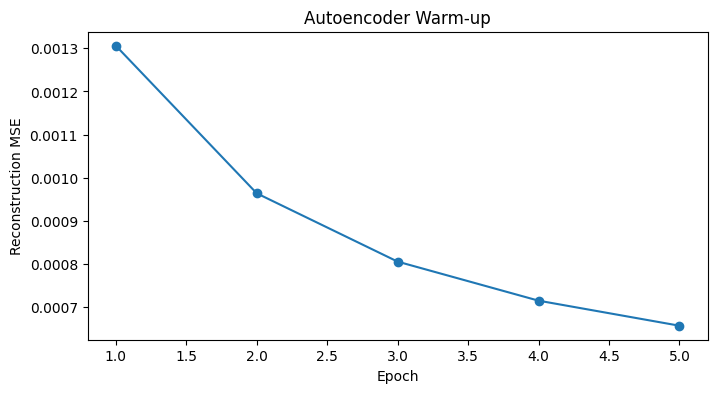

In [29]:
plt.figure(figsize=(8, 4))

plt.plot(
    range(
        1,
        len(warmup_losses)+1
    ),
    warmup_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Reconstruction MSE")
plt.title(
    "Autoencoder Warm-up"
)

plt.show()

In [30]:
model.eval()

latent_vectors = []

with torch.no_grad():

    for (x,) in rq_loader:

        x = x.to(DEVICE)

        z = model.encode(x)

        latent_vectors.append(
            z.cpu().numpy()
        )

latent_vectors = np.concatenate(
    latent_vectors,
    axis=0
)

print(latent_vectors.shape)

(51282, 64)


In [32]:
def initialize_rq_codebooks(
    model,
    latent_vectors,
    codebook_size
):

    residual = latent_vectors.copy()

    for level, codebook in enumerate(
        model.quantizer.codebooks
    ):

        print(
            f"\nInitializing "
            f"codebook {level+1}"
        )

        kmeans = MiniBatchKMeans(
            n_clusters=codebook_size,
            batch_size=4096,
            random_state=(
                SEED + level
            ),
            n_init=5
        )

        labels = kmeans.fit_predict(
            residual
        )

        centers = (
            kmeans.cluster_centers_
            .astype("float32")
        )

        with torch.no_grad():

            codebook.weight.copy_(
                torch.tensor(
                    centers,
                    device=DEVICE
                )
            )

        residual = (
            residual
            -
            centers[labels]
        )

        print(
            "Residual energy:",
            np.mean(
                np.sum(
                    residual**2,
                    axis=1
                )
            )
        )


initialize_rq_codebooks(
    model,
    latent_vectors,
    CODEBOOK_SIZE
)


Initializing codebook 1
Residual energy: 0.6937594

Initializing codebook 2
Residual energy: 0.53959924

Initializing codebook 3
Residual energy: 0.44757703

Initializing codebook 4
Residual energy: 0.37793767


In [33]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-4,
    weight_decay=1e-5
)

rq_history = []

for epoch in range(
    RQ_EPOCHS
):

    model.train()

    totals = defaultdict(float)

    count = 0

    for (x,) in tqdm(
        rq_loader,
        desc=f"RQ {epoch+1}"
    ):

        x = x.to(DEVICE)

        out = model(x)

        recon_loss = F.mse_loss(
            out["reconstruction"],
            x
        )

        loss = (
            recon_loss
            +
            out["vq_loss"]
        )

        optimizer.zero_grad()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        n = x.size(0)

        totals["loss"] += (
            loss.item() * n
        )

        totals["recon"] += (
            recon_loss.item()
            * n
        )

        totals["vq"] += (
            out["vq_loss"].item()
            * n
        )

        count += n

    metrics = {
        k: v / count
        for k, v
        in totals.items()
    }

    rq_history.append(
        metrics
    )

    print(
        f"epoch={epoch+1} "
        f"total={metrics['loss']:.5f} "
        f"recon={metrics['recon']:.5f} "
        f"vq={metrics['vq']:.5f}"
    )

RQ 1:   0%|          | 0/101 [00:00<?, ?it/s]

epoch=1 total=0.01630 recon=0.00085 vq=0.01544


RQ 2:   0%|          | 0/101 [00:00<?, ?it/s]

epoch=2 total=0.00531 recon=0.00089 vq=0.00441


RQ 3:   0%|          | 0/101 [00:00<?, ?it/s]

...

epoch=8 total=0.00151 recon=0.00086 vq=0.00065


RQ 9:   0%|          | 0/101 [00:00<?, ?it/s]

epoch=9 total=0.00151 recon=0.00085 vq=0.00065


RQ 10:   0%|          | 0/101 [00:00<?, ?it/s]

epoch=10 total=0.00151 recon=0.00085 vq=0.00066


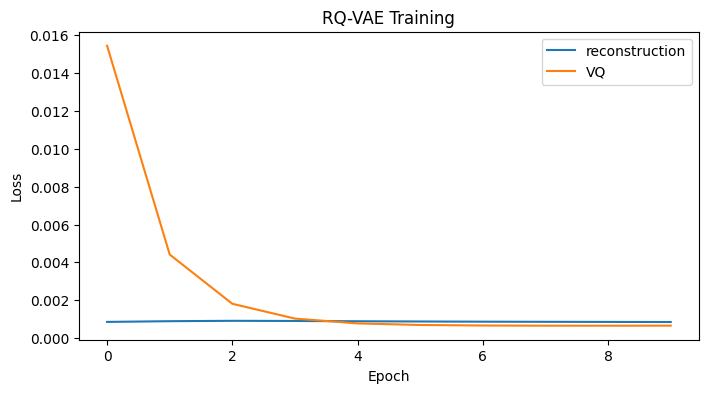

In [34]:
plt.figure(figsize=(8, 4))

plt.plot(
    [
        x["recon"]
        for x in rq_history
    ],
    label="reconstruction"
)

plt.plot(
    [
        x["vq"]
        for x in rq_history
    ],
    label="VQ"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.title(
    "RQ-VAE Training"
)

plt.show()

In [36]:
@torch.no_grad()
def get_semantic_ids(
    model,
    embeddings,
    batch_size=1024
):

    model.eval()

    output_ids = []

    for start in tqdm(
        range(
            0,
            len(embeddings),
            batch_size
        )
    ):

        x = torch.tensor(
            embeddings[
                start:
                start+batch_size
            ],
            dtype=torch.float32,
            device=DEVICE
        )

        z = model.encode(x)

        _, indices, _, _ = (
            model.quantizer(z)
        )

        output_ids.append(
            indices.cpu().numpy()
        )

    return np.concatenate(
        output_ids,
        axis=0
    )


semantic_ids = get_semantic_ids(
    model,
    article_embeddings,
    batch_size=1024
)

print(semantic_ids.shape)

print(
    semantic_ids[:10]
)

  0%|          | 0/64 [00:00<?, ?it/s]

(65238, 4)
[[60 38 60 55]
 [35  6 21  1]
 [47 39 42 13]
 [16  6 59 47]
 [35 59 35 10]
 [40 63 49 41]
 [20 59 52 29]
 [57 14 54 58]
 [22  3 42 45]
 [20 10 18 26]]


In [37]:
for level in range(
    NUM_CODEBOOKS
):

    all_news[
        f"sid_{level+1}"
    ] = semantic_ids[:, level]


all_news[
    [
        "news_id",
        "category",
        "title",
        "sid_1",
        "sid_2",
        "sid_3",
        "sid_4"
    ]
].head(20)

,news_id,category,title,sid_1,sid_2,sid_3,sid_4
0,N55528,lifestyle,"The Brands Queen Elizabeth, Prince Charles, an...",60,38,60,55
1,N19639,health,50 Worst Habits For Belly Fat,35,6,21,1
2,N61837,news,The Cost of Trump's Aid Freeze in the Trenches...,47,39,42,13
3,N53526,health,I Was An NBA Wife. Here's How It Affected My M...,16,6,59,47
4,N38324,health,"How to Get Rid of Skin Tags, According to a De...",35,59,35,10
5,N2073,sports,Should NFL be able to fine players for critici...,40,63,49,41
6,N49186,weather,It's been Orlando's hottest October ever so fa...,20,59,52,29
7,N59295,news,Chile: Three die in supermarket fire amid prot...,57,14,54,58
8,N24510,entertainment,Best PS5 games: top PlayStation 5 titles to lo...,22,3,42,45
9,N39237,news,"How to report weather-related closings, delays",20,10,18,26


In [38]:
def format_sid(sid):

    return "".join(
        [
            f"<L{i}:{code}>"
            for i, code
            in enumerate(sid)
        ]
    )


for i in range(10):

    print(
        all_news.iloc[i].news_id,
        "→",
        format_sid(
            semantic_ids[i]
        )
    )

N55528 → <L0:60><L1:38><L2:60><L3:55>
N19639 → <L0:35><L1:6><L2:21><L3:1>
N61837 → <L0:47><L1:39><L2:42><L3:13>
N53526 → <L0:16><L1:6><L2:59><L3:47>
N38324 → <L0:35><L1:59><L2:35><L3:10>
N2073 → <L0:40><L1:63><L2:49><L3:41>
N49186 → <L0:20><L1:59><L2:52><L3:29>
N59295 → <L0:57><L1:14><L2:54><L3:58>
N24510 → <L0:22><L1:3><L2:42><L3:45>
N39237 → <L0:20><L1:10><L2:18><L3:26>


In [39]:
def codebook_statistics(
    semantic_ids
):

    rows = []

    for level in range(
        semantic_ids.shape[1]
    ):

        counts = np.bincount(
            semantic_ids[:, level],
            minlength=CODEBOOK_SIZE
        )

        probs = (
            counts
            /
            counts.sum()
        )

        probs_nonzero = probs[
            probs > 0
        ]

        entropy = -np.sum(
            probs_nonzero
            *
            np.log(
                probs_nonzero
            )
        )

        perplexity = np.exp(
            entropy
        )

        rows.append(
            {
                "level": level + 1,
                "codes_used":
                    np.sum(
                        counts > 0
                    ),

                "codebook_size":
                    CODEBOOK_SIZE,

                "perplexity":
                    perplexity,

                "max_frequency":
                    counts.max(),

                "min_nonzero":
                    counts[
                        counts > 0
                    ].min()
            }
        )

    return pd.DataFrame(rows)


codebook_statistics(
    semantic_ids
)

,level,codes_used,codebook_size,perplexity,max_frequency,min_nonzero
0,1,30,64,27.632950,4270,458
1,2,35,64,29.926902,3706,1
2,3,47,64,41.631662,2446,1
3,4,53,64,49.239200,2008,6


If:
codebook_size = 64
perplexity ≈ 60

excellent utilization.
If:
perplexity = 4

you probably have codebook collapse.
This is one of the main problems researchers investigate in Semantic-ID tokenizers. Recent work explicitly studies codebook utilization, boundary robustness, reconstruction fidelity, and effective codebook capacity as separate aspects of Semantic-ID quality.

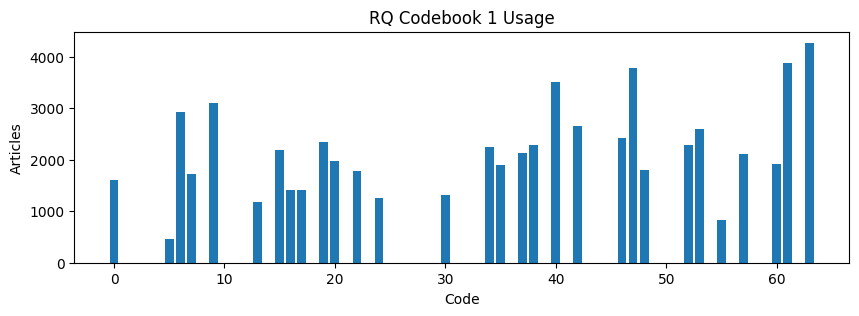

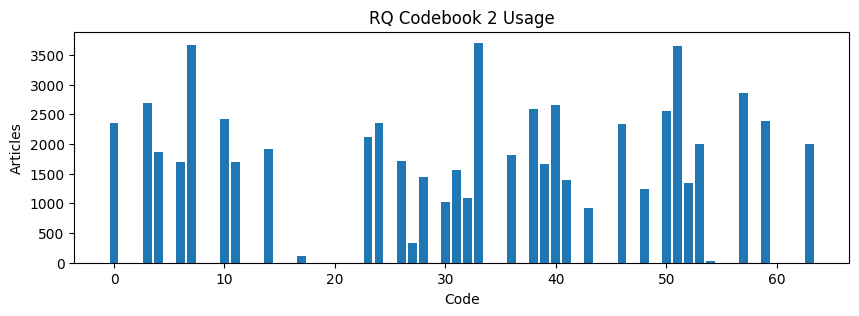

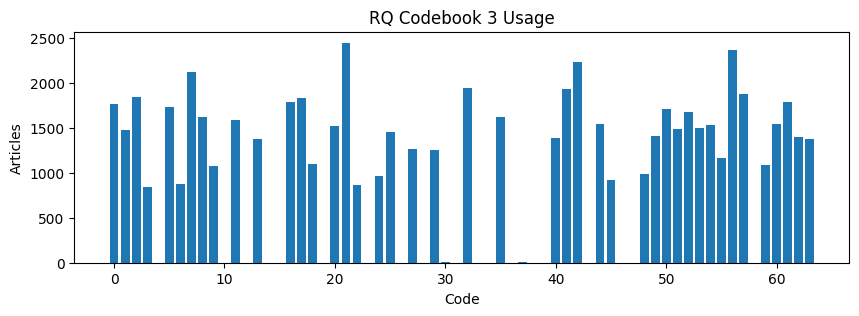

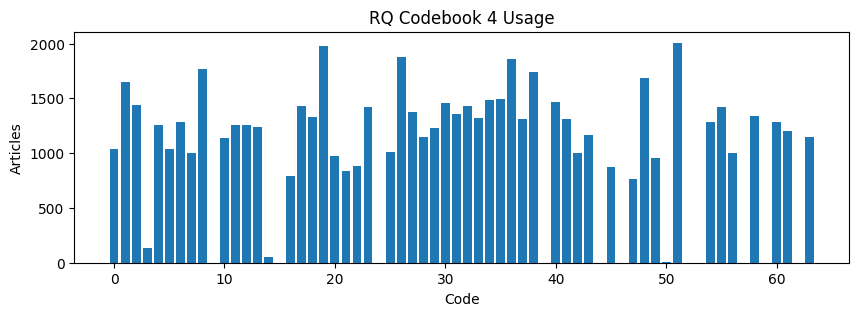

In [40]:
for level in range(
    NUM_CODEBOOKS
):

    counts = np.bincount(
        semantic_ids[:, level],
        minlength=CODEBOOK_SIZE
    )

    plt.figure(
        figsize=(10, 3)
    )

    plt.bar(
        np.arange(
            CODEBOOK_SIZE
        ),
        counts
    )

    plt.xlabel("Code")
    plt.ylabel("Articles")

    plt.title(
        f"RQ Codebook "
        f"{level+1} Usage"
    )

    plt.show()

In [41]:
sid_tuples = [
    tuple(x)
    for x in semantic_ids
]

sid_counter = Counter(
    sid_tuples
)

unique_sids = len(
    sid_counter
)

colliding_groups = {
    sid: count
    for sid, count
    in sid_counter.items()
    if count > 1
}

print(
    "Articles:",
    len(all_news)
)

print(
    "Unique semantic IDs:",
    unique_sids
)

print(
    "Uniqueness rate:",
    unique_sids
    /
    len(all_news)
)

print(
    "Collision groups:",
    len(colliding_groups)
)

print(
    "Largest collision:",
    max(
        sid_counter.values()
    )
)

Articles: 65238
Unique semantic IDs: 55368
Uniqueness rate: 0.8487078083325669
Collision groups: 6558
Largest collision: 35


Collisions aren't automatically a bug.
Two highly similar articles might reasonably receive:
[15, 8, 21, 44]

However, a production generative retrieval system usually needs a strategy for final item disambiguation.

In [42]:
sid_to_indices = defaultdict(
    list
)

for i, sid in enumerate(
    sid_tuples
):

    sid_to_indices[sid].append(i)


collision_examples = [
    (sid, idxs)
    for sid, idxs
    in sid_to_indices.items()
    if len(idxs) > 1
]

for sid, idxs in collision_examples[:5]:

    print(
        "\nSemantic ID:",
        sid
    )

    for idx in idxs[:10]:

        print(
            " -",
            all_news.iloc[idx].title
        )


Semantic ID: (np.int64(35), np.int64(6), np.int64(21), np.int64(1))
 - 50 Worst Habits For Belly Fat
 - This Is Exactly How Long You Need to Hold a Plank to Flatten Your Belly

Semantic ID: (np.int64(47), np.int64(39), np.int64(42), np.int64(13))
 - The Cost of Trump's Aid Freeze in the Trenches of Ukraine's War
 - Trump declares 'big success' in Syria, lifts sanctions on Turkey
 - Turkey Gathered Information in the U.S. Against Its Critics
 - Trump announces 50 million dollars in aid to support Christians and other religious minorities in Syria

Semantic ID: (np.int64(35), np.int64(33), np.int64(54), np.int64(58))
 - 50 Foods You Should Never Eat, According to Health Experts
 - Does It Matter How Much Meat You Eat?

Semantic ID: (np.int64(35), np.int64(48), np.int64(63), np.int64(13))
 - 25 Biggest Grocery Store Mistakes Making You Gain Weight
 - Stay Up & Save: Healthy eating on a budget

Semantic ID: (np.int64(30), np.int64(6), np.int64(42), np.int64(36))
 - PGA Tour winners
 - Tig

Prefix 1: 0.6237
Prefix 2: 0.6569
Prefix 3: 0.6987
Prefix 4: 0.7883
Random-pair similarity: 0.5329389585256576


/tmp/ipykernel_10796/1322007918.py:121: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


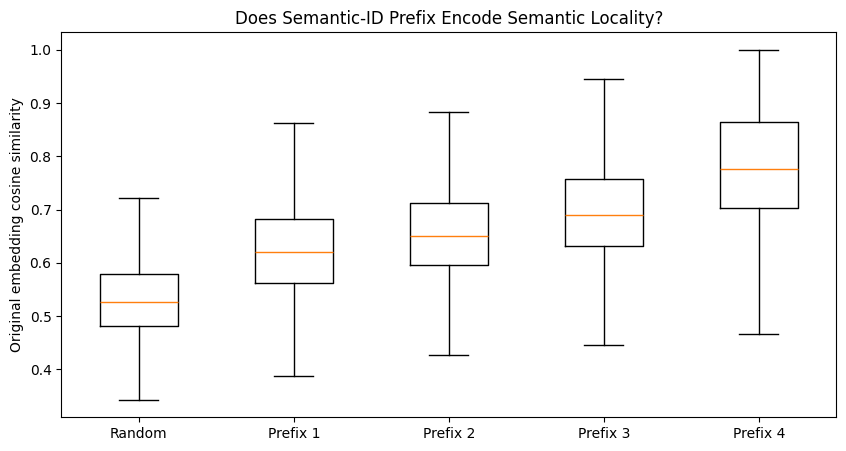

In [45]:
rng = np.random.default_rng(
    SEED
)


def sample_same_prefix_similarity(
    depth,
    max_pairs=3000
):

    groups = defaultdict(
        list
    )

    for i, sid in enumerate(
        sid_tuples
    ):

        groups[
            sid[:depth]
        ].append(i)

    valid_groups = [
        g
        for g in groups.values()
        if len(g) >= 2
    ]

    similarities = []

    for _ in range(max_pairs):

        group = random.choice(
            valid_groups
        )

        a, b = random.sample(
            group,
            2
        )

        similarities.append(
            float(
                article_embeddings[a]
                @
                article_embeddings[b]
            )
        )

    return similarities


prefix_results = {}

for depth in range(
    1,
    NUM_CODEBOOKS + 1
):

    sims = (
        sample_same_prefix_similarity(
            depth
        )
    )

    prefix_results[depth] = sims

    print(
        f"Prefix {depth}: "
        f"{np.mean(sims):.4f}"
    )
random_sims = []

for _ in range(3000):

    a, b = rng.choice(
        len(all_news),
        size=2,
        replace=False
    )

    random_sims.append(
        float(
            article_embeddings[a]
            @
            article_embeddings[b]
        )
    )

print(
    "Random-pair similarity:",
    np.mean(
        random_sims
    )
)
data = [
    random_sims
]

labels = [
    "Random"
]

for depth in range(
    1,
    NUM_CODEBOOKS + 1
):

    data.append(
        prefix_results[depth]
    )

    labels.append(
        f"Prefix {depth}"
    )

plt.figure(
    figsize=(10, 5)
)

plt.boxplot(
    data,
    labels=labels,
    showfliers=False
)

plt.ylabel(
    "Original embedding cosine similarity"
)

plt.title(
    "Does Semantic-ID Prefix Encode Semantic Locality?"
)

plt.show()

In [46]:
query_idx = 100

query_sid = tuple(
    semantic_ids[
        query_idx
    ]
)

print("QUERY")
print(
    all_news.iloc[
        query_idx
    ].title
)

print(
    "\nSID:",
    query_sid
)


def common_prefix_length(
    a,
    b
):

    count = 0

    for x, y in zip(a, b):

        if x != y:
            break

        count += 1

    return count


results = []

for idx, sid in enumerate(
    sid_tuples
):

    if idx == query_idx:
        continue

    prefix = (
        common_prefix_length(
            query_sid,
            sid
        )
    )

    if prefix > 0:

        similarity = float(
            article_embeddings[
                query_idx
            ]
            @
            article_embeddings[
                idx
            ]
        )

        results.append(
            (
                prefix,
                similarity,
                idx,
                sid
            )
        )


results = sorted(
    results,
    reverse=True
)

for (
    prefix,
    similarity,
    idx,
    sid
) in results[:20]:

    print()
    print(
        "prefix:",
        prefix,
        "cosine:",
        round(
            similarity,
            3
        )
    )

    print(
        sid,
        all_news.iloc[idx].title
    )

QUERY
14 Celebs Over 50 Who Are In The Best Shape Of Their Lives

SID: (np.int64(42), np.int64(28), np.int64(54), np.int64(56))

prefix: 3 cosine: 0.662
(np.int64(42), np.int64(28), np.int64(54), np.int64(2)) You're never too old! Celebrities who found love after 40

prefix: 2 cosine: 0.716
(np.int64(42), np.int64(28), np.int64(24), np.int64(45)) Ballet star, 100, shares optimism and other secrets to long life

prefix: 2 cosine: 0.715
(np.int64(42), np.int64(28), np.int64(32), np.int64(34)) Inside Adele's new fitness routine, plus more news

prefix: 2 cosine: 0.713
(np.int64(42), np.int64(28), np.int64(7), np.int64(42)) Mom of six fought terminal breast cancer to live for her kids. They started living for her

prefix: 2 cosine: 0.71
(np.int64(42), np.int64(28), np.int64(61), np.int64(28)) Need a Boost? These Genius Inspirational Quotes Work Wonders

prefix: 2 cosine: 0.71
(np.int64(42), np.int64(28), np.int64(52), np.int64(58)) Jessica Simpson's Personal Trainer Reveals How She Dropped

In [47]:
import numpy as np
import pandas as pd


def analyze_codebooks(
    semantic_ids,
    codebook_size
):
    rows = []

    for level in range(
        semantic_ids.shape[1]
    ):

        ids = semantic_ids[:, level]

        counts = np.bincount(
            ids,
            minlength=codebook_size
        )

        probs = (
            counts / counts.sum()
        )

        nz = probs > 0

        entropy = -np.sum(
            probs[nz] *
            np.log(
                probs[nz] + 1e-12
            )
        )

        perplexity = np.exp(
            entropy
        )

        utilization = (
            np.count_nonzero(counts)
            /
            codebook_size
        )

        rows.append({
            "level":
                level + 1,

            "codes_used":
                np.count_nonzero(
                    counts
                ),

            "K":
                codebook_size,

            "utilization":
                utilization,

            "entropy":
                entropy,

            "perplexity":
                perplexity,

            "largest_cluster_pct":
                counts.max()
                /
                counts.sum()
        })

    return pd.DataFrame(rows)


analyze_codebooks(
    semantic_ids,
    CODEBOOK_SIZE
)

,level,codes_used,K,utilization,entropy,perplexity,largest_cluster_pct
0,1,30,64,0.468750,3.319009,27.632950,0.065453
1,2,35,64,0.546875,3.398758,29.926902,0.056807
2,3,47,64,0.734375,3.728861,41.631662,0.037493
3,4,53,64,0.828125,3.896690,49.239200,0.030780
